# Intro to Data Science and AI - Final exam - 2026

In this exam you will use the file **"startups.csv"** to undertake several tasks. The exam is marked out of 60. Complete all tasks.

The file is available via BrightSpace. 

Each row in the dataset represents a company, with the following features:

- *Company*: the numerical id of the company 
- *Country*: the country in which the company is located 
- *R&D*: the annual company spend on research and development
- *Admin*: the annual company spend on adminstration
- *Marketing*: the annual company spend on marketing
- *Profit*: the profit of the company 


# Task 1 - data manipulation

#### Download the file and load the data into a Pandas DataFrame. Use the Company column as the index. 

#### Print the descriptive statistics for the numeric columns.

**Marks = 5**


In [3]:
import pandas as pd

df = pd.read_csv("startups.csv")
df.describe()

,Company,R&D,Admin,Marketing,Profit
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,73721.615600,121344.639600,211025.097800,112012.639200
std,14.57738,45902.256482,28017.802755,122290.310726,40306.180338
min,1.00000,0.000000,51283.140000,0.000000,14681.400000
25%,13.25000,39936.370000,103730.875000,129300.132500,90138.902500
50%,25.50000,73051.080000,122699.795000,212716.240000,107978.190000
75%,37.75000,101602.800000,144842.180000,299469.085000,139765.977500
max,50.00000,165349.200000,182645.560000,471784.100000,192261.830000


#### Calculate and print the number of companies in each country in the dataset. What country has the most startups?
**Marks = 5**

In [4]:
df["Country"].value_counts()

Country
Ireland    15
Spain      10
France      9
Germany     9
England     7
Name: count, dtype: int64

Ireland has the most startups


#### Calculate and print the mean profit by country for companies in the dataset. The values should be printed as integer values. What country had the highest mean profit? 

**Marks = 10**

In [5]:
Ireland = df.loc[df["Country"] == "Ireland"]
Spain = df.loc[df["Country"] == "Spain"]
France = df.loc[df["Country"] == "France"]
Germany = df.loc[df["Country"] == "Germany"]
England = df.loc[df["Country"] == "England"]

IrelandMean = int(Ireland["Profit"].mean())
SpainMean = int(Spain["Profit"].mean())
FranceMean = int(France["Profit"].mean())
GermanyMean = int(Germany["Profit"].mean())
EnglandMean = int(England["Profit"].mean())

print(f"Ireland has a mean profit of {IrelandMean}")
print(f"Spain has a mean profit of {SpainMean}")
print(f"France has a mean profit of {FranceMean}")
print(f"Germany has a mean profit of {GermanyMean}")
print(f"England has a mean profit of {EnglandMean}")


Ireland has a mean profit of 104568
Spain has a mean profit of 107335
France has a mean profit of 135941
Germany has a mean profit of 94493
England has a mean profit of 126405


France had the highest profit

# Task 2 - Linear regrassion


#### Create a new column in the dataframe called "Total Spend" that shows the total annual spend of each company, i.e the combined spend on R&D, administration and marketing. Display the first five rows of the new dataframe.
**Marks = 5**


In [6]:
df["TotalSpend"] = df["R&D"] + df["Admin"] + df["Marketing"]

df.head(5)

,Company,Country,R&D,Admin,Marketing,Profit,TotalSpend
0,1,Ireland,1000.23,124153.04,1903.93,64926.08,127057.20
1,2,England,78389.47,153773.43,299737.29,111313.02,531900.19
2,3,France,20229.59,65947.93,185265.10,81229.06,271442.62
3,4,Spain,78013.11,121597.55,264346.06,126992.93,463956.72
4,5,Ireland,0.00,135426.92,0.00,42559.73,135426.92


#### Apply a **simple linear regression** to learn (fit) a model, where *Total Spend* is the independent variable and *Profit* is the target variable that we would like to predict. 
**Marks = 10**

#### Print out the slope and intercept coefficients for the model to two decimal places.
**Marks = 5**

In [7]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression

x = df[["TotalSpend"]].values
y = df[["Profit"]]

model = LinearRegression()
model.fit(x, y)

print("Coefficient (slope): %.2f" % model.coef_[0][0])
print("Intercept: %.2f" % model.intercept_[0])


Coefficient (slope): 0.22
Intercept: 24075.44


#### Create a scatterplot of "Total Spend" vs "Profit" that also shows the regression line for the model above. Add appropriate labels to the x and y axis. 

**Marks = 15**

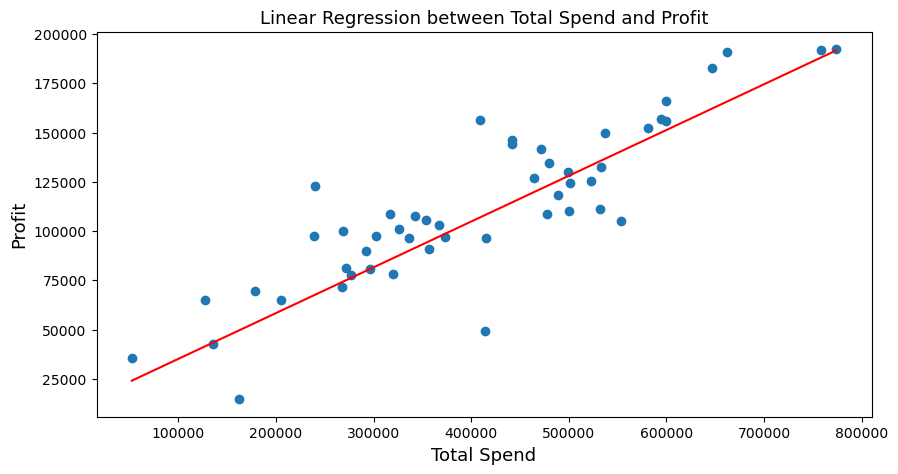

In [8]:
m = model.coef_[0]
b = model.intercept_

plt.figure(figsize=(10, 5))
plt.scatter(x, y)
plt.plot([min(x), max(x)], [b, m*max(x) + b], 'r')

plt.xlabel("Total Spend", fontsize=13)
plt.ylabel("Profit", fontsize=13)
plt.title("Linear Regression between Total Spend and Profit", fontsize=13)

plt.show()

#### Using the model estimate the profit of a company that has a total spend of €700000
**Marks = 5**

In [52]:
company_unseen = [[700000]]
model.predict(company_unseen)

print(f"The model estimate for a company with a spend of 700,000 will have a profit of {model.predict(company_unseen)[0][0]:.2f}")

The model estimate for a company with a spend of 700,000 will have a profit of 175657.19
